# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, current_beam):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - current_beam**2)
    final_bmin_as = np.sqrt(bmin_as**2 - current_beam**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def calculate_resolution2( clean_beam, current_beam):
    from radio_beam import Beam
    bmaj_clean = clean_beam['bmaj']
    bmin_clean = clean_beam['bmin']
    bpa_deg_clean = clean_beam['beam_pa']

    bmaj_current = current_beam['bmaj']
    bmin_current = current_beam['bmin']
    bpa_deg_current = current_beam['beam_pa']

    beam_orig =  Beam(major=bmaj_current*u.arcsec, minor=bmin_current*u.arcsec, pa=bpa_deg_current)
    beam_target = Beam(major=bmaj_clean*u.arcsec, minor=bmin_clean*u.arcsec, pa=bpa_deg_clean)

    beam_final = beam_target.deconvolve(beam_orig)

    #return values in a dict
    final_resolution = {'bmaj': beam_final.major.to(u.arcsec).value,
                        'bmin': beam_final.minor.to(u.arcsec).value,
                        'beam_pa': beam_final.pa.to(u.deg).value}

    return final_resolution


In [7]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [8]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

In [9]:
def create_disk_image_blob_jy_per_pixel(
    N=500,                         # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.4, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.05, 0.02, 0.05], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=0.1,                  # Core amplitude (Jy/pixel)
    amp_rings=[0.05, 0.04, 0.03],  # Rings amplitude (Jy/pixel)
    m_modes=[1, 0, 0],             # Asymmetry mode (1 -> blob, 0 -> ring)
    theta0=[np.pi, 0, 0],     # Blob position angle (radians)
    amp_asym=[0.9, 0, 0]           # Asymmetry/blob amplitude (fraction of amp_rings)
):
    """
    Creates a synthetic disk image directly in Jy/pixel by summing
    Gaussian and annular components in the image plane.
    """
    
    # 1. Prepare coordinate grid and radii
    
    # Pixel coordinates (in arcsec, with center at (0, 0))
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    # Create the 2D grid of coordinates and radii
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X) # Polar angle of each pixel
    
    # Initialize the total image in Jy/pixel
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # 2. Add the Central Gaussian Core
    
    # 2D Gaussian Formula: I(r) = A * exp(- (r^2 / (2 * sigma^2)))
    # Note: Your original code uses exp(-2 * (pi * sigma * baseline)^2), 
    # which is the FT of a Gaussian. In the image plane, we use the standard form:
    sigma_image = sigma_core / np.sqrt(2 * np.log(2)) # Approximation FWHM -> sigma (Commented out line, original uses sigma_core directly)
    
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # 3. Add Rings and Blobs
    
    # Iterate over the properties of each component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):
        
        # Symmetric Ring (Gaussian centered at radius R)
        # Formula: I(r) = A * exp(-(r - R)^2 / (2 * w^2))
        I_ring = A * np.exp(-0.5 * ((R_image - R) / w)**2)
        I_disk_jy_per_pixel += I_ring
        
        # Asymmetric Blobs (Displaced Gaussian)
        if m != 0 and Aasym > 0:
            
            # Blob center position (in arcsec)
            x0 = R * np.cos(th0)
            y0 = R * np.sin(th0)
            
            # Coordinate offset
            X_blob = X - x0
            Y_blob = Y - y0
            R_blob_sq = X_blob**2 + Y_blob**2
            
            # Blob amplitude (fraction of the ring)
            A_blob = Aasym * A
            
            # Blob Gaussian (centered at (x0, y0))
            I_blob = A_blob * np.exp(-0.5 * (R_blob_sq / w_blob**2))
            
            I_disk_jy_per_pixel += I_blob
            
    return I_disk_jy_per_pixel

# Data

In [10]:
# UVtable
dir = "../../data/uvtable/"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Load data
file = np.loadtxt(data_file, unpack = True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [11]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [12]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [13]:
Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [14]:
imsize = N

In [15]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [16]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [42]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
best_N100 = {'m': -2.935881163664834, 'c': 79471204676386.11, 'l': 45256.57763586783}

In [43]:
best_N50_Rmax5 = {'m': -1.972719134084518, 'c': 58157011.81131077, 'l': 26595.265124130965}

In [44]:
best = best_N100

In [45]:
frank2d = Frank2D(N, Rmax)

In [46]:
start_time = time.time()
frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.935881163664834, 'c': 79471204676386.11, 'l': 45256.57763586783}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  1.64 seconds
        +  Building system = 0.03  min |  1.67 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 221/50000 [00:29<1:50:28,  7.51 iterations/s]


            +  BiCGStab = 0.49  min |  29.43 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 221,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.23  min |  13.99 seconds
--> times building full visibility model = 0.23  min |  14.02 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 took 49.077476501464844 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [47]:
Plot_ = Plot(frank2d, geom_f2d)

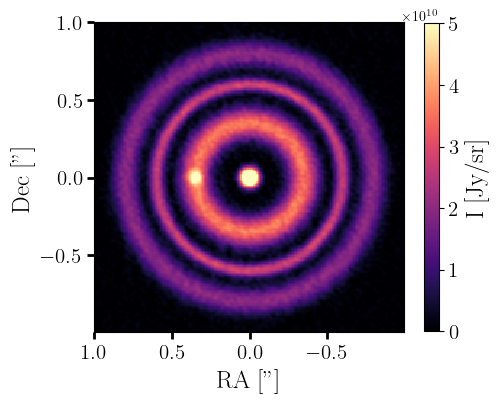

In [48]:
Plot_.intensity(gamma=1, zoom=3, vmax = 5e10, title="", fig_size=5, 
tick_label_size = 15, label_size = 18, title_size = 18)

### CLEAN from .model

In [49]:
from astropy.io import fits
dir_  = "../../data/.model_fits/"

disk = "SimulatedBlob_dotmodel_imsize642_cellsize0p009.fits"

fits_name = dir_ + disk
hdul = fits.open(fits_name)

In [50]:
hdr = hdul[0].header
data = hdul[0].data 
data = np.squeeze(data)

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
w = WCS(hdr)

if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)

# img comes without the beam convolutded
Img_clean_model =  img/(frank2d.FT._dx * frank2d.FT._dy)
vis_clean = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))


In [51]:
clean_img = Img_clean_model

## Comparing with the ground thruth

In [52]:
N = frank2d.Nx
dx = frank2d.dx # arcsec
dxy = dx/rad_to_arcsec
type_ ="Blob"
amp_core_ajustado = 0.00025 
amp_rings_ajustado = [0.000086, 0.000070, 0.000050] 
amp_asym_ajustado = [0.65, 0, 0]

reference_image = create_disk_image_blob_jy_per_pixel(
    N=N,                         # Image size (N x N pixels)
    pixel_scale_arcsec=dx,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.35, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.07, 0.03, 0.06], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=amp_core_ajustado,    # Core amplitude (Jy/pixel)
    amp_rings=amp_rings_ajustado,  # Rings amplitude (Jy/pixel)
    amp_asym=amp_asym_ajustado,
    theta0=[np.pi, 0, 0],
    m_modes=[1, 0, 0])

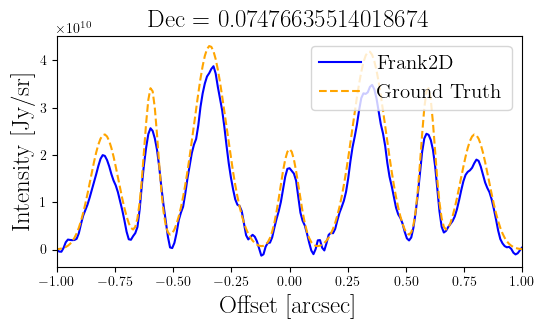

In [53]:
index_x = int(N/2 +8)

#frank2d
I_f2d = frank2d.intensity_model[index_x]
x = frank2d.x_grid[0]*rad_to_arcsec
y_i = frank2d.y_grid[index_x][0]*rad_to_arcsec

# Cálculo del área sólida (en sr)
sigma_sr =  (dx/rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr
I_ground_truth = image_jy_per_sr[index_x]

plt.figure(figsize=(6,3))
plt.plot(x, I_f2d, label='Frank2D', color='blue')
plt.plot(x, I_ground_truth, label='Ground Truth', color='orange', linestyle='dashed')
plt.xlabel('Offset [arcsec]', size=18)
plt.ylabel('Intensity [Jy/sr]', size=18)
plt.title('Dec = ' + str(y_i), size=18)
plt.legend(fontsize=15)
plt.xlim(-rout, rout)
plt.show()

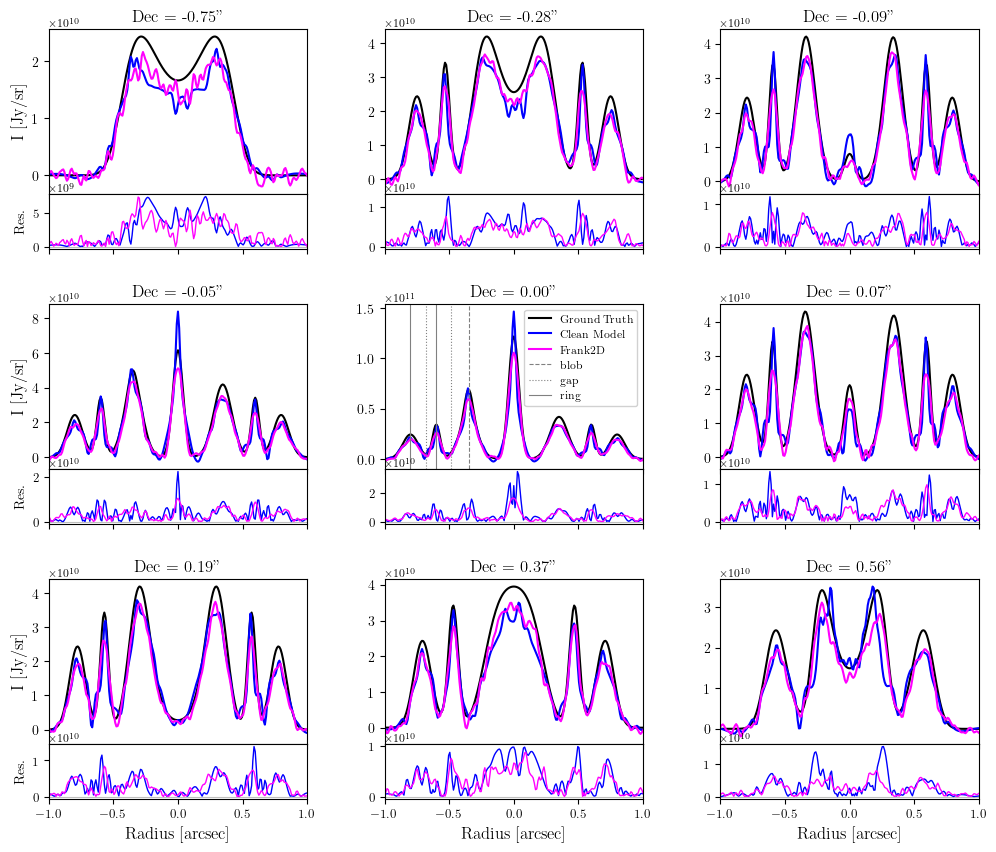

In [54]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np

# --- TUS DATOS (Tal cual los tenías) ---
indices_seleccionados = [
    int(N/2 - 80),
    int(N/2 - 30),  
    int(N/2 - 10), 
    int(N/2 - 5), 
    int(N/2), 
    int(N/2 + 8),
    int(N/2 + 20), 
    int(N/2 + 40), 
    int(N/2 + 60)
]

sigma_sr = (dx / rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr

# --- INICIO DE LA FIGURA ---
fig = plt.figure(figsize=(12, 10)) # Aumenté un poco el alto para que quepan los residuales
# Creamos una grilla de 3x3 para los paneles generales
outer_grid = gridspec.GridSpec(3, 3, wspace=0.3, hspace=0.25)

for i in range(len(indices_seleccionados)):
    idx = indices_seleccionados[i]

    # --- DATOS ---
    I_f2d = frank2d.intensity_model[idx]
    x = frank2d.x_grid[0] * rad_to_arcsec
    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    I_ground_truth = image_jy_per_sr[idx]
    I_clean = clean_img[idx]
    
    # Calcular Residuales (Modelo - Verdad)
    res_clean = np.abs(I_clean - I_ground_truth)
    res_frank = np.abs(I_f2d - I_ground_truth)

    # --- SUB-GRILLA (Imagen arriba, Residual abajo) ---
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1,
                    subplot_spec=outer_grid[i], wspace=0, hspace=0, height_ratios=[3, 1])
    
    ax_main = plt.subplot(inner_grid[0])
    ax_res = plt.subplot(inner_grid[1], sharex=ax_main)

    # Definir etiquetas SOLO para el gráfico central (i=4)
    lbl_gt = 'Ground Truth' if i == 4 else None
    lbl_cl = 'Clean Model' if i == 4 else None
    lbl_fr = 'Frank2D' if i == 4 else None

    # --- PLOT PRINCIPAL ---
    ax_main.plot(x, I_ground_truth, label=lbl_gt, color='black', linestyle='-')
    ax_main.plot(x, I_clean, label=lbl_cl, color='blue', linestyle='-')
    ax_main.plot(x, I_f2d, label=lbl_fr, color='magenta', ls='-')

    ax_main.set_title(f' Dec = {y_i:.2f}"', size=12)
    ax_main.set_xlim(-rout, rout)
    ax_main.tick_params(labelbottom=False) # Quitar números del eje X en el gráfico de arriba

    # --- DETALLES SOLO EN EL CENTRO (i == 4) ---
    if i == 4:
        ax_main.axvline(-0.35, color='gray', linestyle='--', linewidth=0.8, label=r"blob")
        ax_main.axvline(-0.49, color='gray', linestyle='dotted', linewidth=0.8, label="gap")
        ax_main.axvline(-0.6, color='gray', linestyle='-', linewidth=0.8, label="ring")
        ax_main.axvline(-0.68, color='gray', linestyle='dotted', linewidth=0.8)
        ax_main.axvline(-0.8, color='gray', linestyle='-', linewidth=0.8)
        
        # Leyenda unificada
        ax_main.legend(fontsize=8, loc='upper right', framealpha=0.9)

    # --- PLOT RESIDUALES ---
    ax_res.axhline(0, color='gray', lw=0.8, alpha=0.5)
    ax_res.plot(x, res_clean, color='blue', linestyle='-', lw=1)
    ax_res.plot(x, res_frank, color='magenta', ls='-', lw=1)

    # --- ETIQUETAS DE EJES ---
    # Solo en la columna izquierda
    if i % 3 == 0:
        ax_main.set_ylabel('I [Jy/sr]', size=12)
        ax_res.set_ylabel('Res.', size=10)
    
    # Solo en la fila inferior
    if i >= 6:
        ax_res.set_xlabel('Radius [arcsec]', size=12)
    else:
        ax_res.tick_params(labelbottom=False) # Si no es la fila de abajo, quitar ticks X

    # --- FORMATO CIENTÍFICO ---
    # Para que los números grandes (1e11) no se vean feos
    #formatter = mticker.ScalarFormatter(useMathText=True)
    #formatter.set_powerlimits((-2, 2))
    
    #ax_main.yaxis.set_major_formatter(formatter)
    #ax_res.yaxis.set_major_formatter(formatter)
    
    # Ajustar tamaño de ticks
    ax_main.tick_params(axis='both', labelsize=10)
    ax_res.tick_params(axis='both', labelsize=9)
    ax_main.yaxis.get_offset_text().set_fontsize(8) # El "1e11" más pequeño
    ax_res.yaxis.get_offset_text().set_fontsize(8)

plt.tight_layout()
plt.show()

In [55]:
import numpy as np
from sklearn.metrics import r2_score

def evaluate_comparison(frank_image, clean_image, truth_image, indices, axis_x_arcsec):
    """
    Comparación cuantitativa entre Frank, Clean y Ground Truth.
    """
    
    # Diccionario para guardar historiales
    metrics = {
        "frank": {"nrmse": [], "flux_rec": [], "peak_err": []},
        "clean": {"nrmse": [], "flux_rec": [], "peak_err": []}
    }
    
    # Encabezado de la tabla (F = Frank, C = Clean)
    print(f"{'Idx':<4} | {'NRMSE F':<8} {'NRMSE C':<8} | {'Flux F':<7} {'Flux C':<7} | {'PeakErr F':<9} {'PeakErr C':<9}")
    print("-" * 75)

    for idx in indices:
        # 1. Extraer los cortes 1D
        cut_truth = truth_image[idx, :]
        cut_frank = frank_image[idx, :]
        cut_clean = clean_image[idx, :]
        
        # Norma de la verdad (para NRMSE) y Flujo de la verdad (para Flux Rec)
        norm_t = np.linalg.norm(cut_truth)
        flux_truth = np.trapz(cut_truth, x=axis_x_arcsec)
        peak_t = np.max(cut_truth)

        # --- CÁLCULOS PARA FRANK ---
        diff_f = cut_frank - cut_truth
        nrmse_f = np.linalg.norm(diff_f) / norm_t if norm_t > 0 else 0.0
        
        flux_f = np.trapz(cut_frank, x=axis_x_arcsec)
        rec_f = flux_f / flux_truth if abs(flux_truth) > 1e-12 else 0.0
        
        peak_f = np.max(cut_frank)
        peak_err_f = (peak_f - peak_t) / peak_t if peak_t > 0 else 0.0

        # --- CÁLCULOS PARA CLEAN ---
        #"""
        diff_c = cut_clean - cut_truth
        nrmse_c = np.linalg.norm(diff_c) / norm_t if norm_t > 0 else 0.0
        
        flux_c = np.trapz(cut_clean, x=axis_x_arcsec)
        rec_c = flux_c / flux_truth if abs(flux_truth) > 1e-12 else 0.0
        
        peak_c = np.max(cut_clean)
        peak_err_c = (peak_c - peak_t) / peak_t if peak_t > 0 else 0.0

                
        metrics["clean"]["nrmse"].append(nrmse_c)
        metrics["clean"]["flux_rec"].append(rec_c)
        metrics["clean"]["peak_err"].append(peak_err_c)
        #"""
        # --- GUARDAR ---
        metrics["frank"]["nrmse"].append(nrmse_f)
        metrics["frank"]["flux_rec"].append(rec_f)
        metrics["frank"]["peak_err"].append(peak_err_f)
        
        # --- IMPRIMIR FILA ---
        # NRMSE con 4 decimales, Flux Rec con 3, Peak Err en porcentaje
        #print(f"{idx:<4} | {nrmse_f:.4f}   {nrmse_c:.4f}   | {rec_f:.3f}   {rec_c:.3f}   | {peak_err_f:+.1%}    {peak_err_c:+.1%}")
        print(f"{idx:<4} | {nrmse_f:.4f}   | {rec_f:.3f}   | {peak_err_f:+.1%} ")


    return metrics

# ==============================================================================
# USO DEL CÓDIGO
# ==============================================================================
x_axis = frank2d.x_grid[0] * rad_to_arcsec 

# Llamamos a la función pasando AMBOS modelos
stats = evaluate_comparison(
    frank2d.intensity_model,  # Modelo Frank
    clean_img,                # Modelo Clean (asegúrate que se llame así tu variable)
    image_jy_per_sr,          # Ground Truth
    indices_seleccionados,
    x_axis
)

# ==============================================================================
# RESUMEN ESTADÍSTICO FINAL (RMS para NRMSE)
# ==============================================================================
# Convertimos a arrays
nrmse_f_vals = np.array(stats["frank"]["nrmse"])
nrmse_c_vals = np.array(stats["clean"]["nrmse"])

flux_f_vals = np.array(stats["frank"]["flux_rec"])
flux_c_vals = np.array(stats["clean"]["flux_rec"])

# Cálculo del RMS (Root Mean Square) para NRMSE
rms_nrmse_f = np.sqrt(np.mean(nrmse_f_vals**2))
rms_nrmse_c = np.sqrt(np.mean(nrmse_c_vals**2))

# Cálculo de media y desviación para Flux Recovery
mean_flux_f = np.mean(flux_f_vals)
std_flux_f = np.std(flux_f_vals)
mean_flux_c = np.mean(flux_c_vals)
std_flux_c = np.std(flux_c_vals)

print("\n" + "="*40)
print("       RESUMEN FINAL (GLOBAL)")
print("="*40)
print(f"{'Métrica':<15} | {'Frank':<10} | {'CLEAN':<10}")
print("-" * 40)
print(f"{'RMS NRMSE':<15} | {rms_nrmse_f:.4f}     | {rms_nrmse_c:.4f}")
print(f"{'Mean Flux Rec':<15} | {mean_flux_f:.3f}      | {mean_flux_c:.3f}")
print(f"{'Std Flux Rec':<15} | {std_flux_f:.3f}      | {std_flux_c:.3f}")
print("-" * 40)

if rms_nrmse_f < rms_nrmse_c:
    print(">> CONCLUSIÓN: Frank tiene menor error global (NRMSE).")
else:
    print(">> CONCLUSIÓN: CLEAN tiene menor error global (NRMSE).")


Idx  | NRMSE F  NRMSE C  | Flux F  Flux C  | PeakErr F PeakErr C
---------------------------------------------------------------------------
241  | 0.1978   | 0.812   | -11.1% 
291  | 0.1661   | 0.824   | -12.5% 
311  | 0.1776   | 0.816   | -10.9% 
316  | 0.1642   | 0.827   | -16.8% 
321  | 0.1514   | 0.830   | -13.3% 
329  | 0.1886   | 0.803   | -9.9% 
341  | 0.1767   | 0.821   | -10.6% 
361  | 0.1784   | 0.816   | -11.5% 
381  | 0.1845   | 0.823   | -9.0% 

       RESUMEN FINAL (GLOBAL)
Métrica         | Frank      | CLEAN     
----------------------------------------
RMS NRMSE       | 0.1767     | 0.2147
Mean Flux Rec   | 0.819      | 0.849
Std Flux Rec    | 0.008      | 0.026
----------------------------------------
>> CONCLUSIÓN: Frank tiene menor error global (NRMSE).


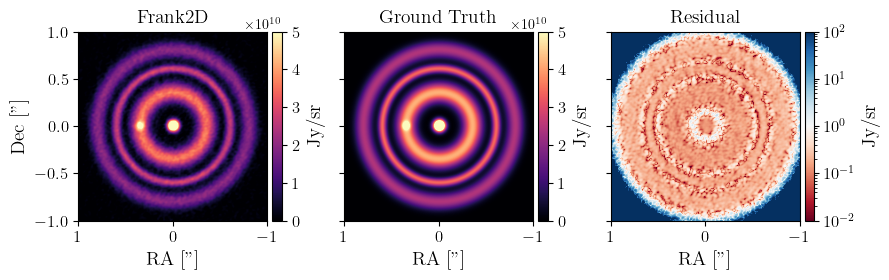

In [58]:
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
I_GT_final = image_jy_per_sr
I_Frank_final = frank2d.intensity_model

# --- CÁLCULO DEL RESIDUAL (Frank - Ground) ---
I_Residual = np.abs((I_Frank_final - I_GT_final)/I_GT_final)

# ==============================================================================
# 4. VISUALIZACIÓN (3 SUBPLOTS)
# ==============================================================================
# Límites para el colormap
vmax_val = max(np.nanmax(I_GT_final), np.nanmax(I_Frank_final))
vmin_val = 0

# Para el residual, usamos una escala simétrica centrada en 0
res_limit = np.max(np.abs(I_Residual))

# Configuración de figura: (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)
extent = [Rmax, -Rmax, -Rmax, Rmax]

# Lista de configuración para iterar
# (Datos, Título, Colormap, Vmin, Vmax)
plots_config = [
    (I_Frank_final, r'Frank2D', 'magma', vmin_val, vmax_val),
    (I_GT_final, "Ground Truth", 'magma', vmin_val, vmax_val),
    (I_Residual, "Residual", 'RdBu', -res_limit, res_limit)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(plots_config):
    ax = axes[i]
    
    # Plotear imagen
    # Usamos PowerNorm solo para intensidad, Linear para residual
    if i < 2: 
        norm = colors.PowerNorm(gamma=1, vmin=vmin, vmax=5e10)
    else:
        norm = colors.LogNorm(vmin = 1e-2, vmax = 1e2)

    im = ax.imshow(data, extent=extent, origin='lower', cmap=cmap, norm=norm)
    
    # Estética
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('RA ["]', fontsize=14)
    ax.set_xlim(rout, -rout)
    ax.set_ylim(-rout, rout)
    if i == 0: ax.set_ylabel('Dec ["]', fontsize=14)
    ax.grid(False)
    
    # Colorbar ajustada al tamaño del subplot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=12)
    ax.tick_params(axis='both', which='both', labelsize=12)
    cbar.set_label('Jy/sr', fontsize=14)

plt.tight_layout()
plt.show()

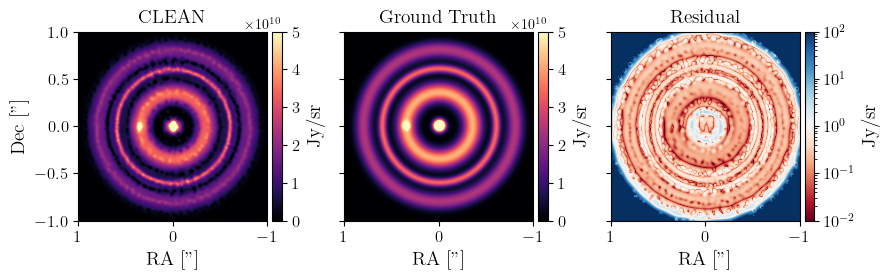

In [57]:
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
I_GT_final = image_jy_per_sr
I_Frank_final = frank2d.intensity_model

# --- CÁLCULO DEL RESIDUAL (Frank - Ground) ---
I_Residual = np.abs((clean_img - I_GT_final)/I_GT_final)

# ==============================================================================
# 4. VISUALIZACIÓN (3 SUBPLOTS)
# ==============================================================================
# Límites para el colormap
vmax_val = max(np.nanmax(I_GT_final), np.nanmax(I_Frank_final))
vmin_val = 0

# Para el residual, usamos una escala simétrica centrada en 0
res_limit = np.max(np.abs(I_Residual))

# Configuración de figura: (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)
extent = [Rmax, -Rmax, -Rmax, Rmax]

# Lista de configuración para iterar
# (Datos, Título, Colormap, Vmin, Vmax)
plots_config = [
    (clean_img, "CLEAN", 'magma', vmin_val, vmax_val),
    (I_GT_final, "Ground Truth", 'magma', vmin_val, vmax_val),
    (I_Residual, "Residual", 'RdBu', -res_limit, res_limit)
]

for i, (data, title, cmap, vmin, vmax) in enumerate(plots_config):
    ax = axes[i]
    
    # Plotear imagen
    # Usamos PowerNorm solo para intensidad, Linear para residual
    if i < 2: 
        norm = colors.PowerNorm(gamma=1, vmin=vmin, vmax=5e10)
    else:
        norm = colors.LogNorm(vmin = 1e-2, vmax = 1e2)

    im = ax.imshow(data, extent=extent, origin='lower', cmap=cmap, norm=norm)
    
    # Estética
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('RA ["]', fontsize=14)
    ax.set_xlim(rout, -rout)
    ax.set_ylim(-rout, rout)
    if i == 0: ax.set_ylabel('Dec ["]', fontsize=14)
    ax.grid(False)
    
    # Colorbar ajustada al tamaño del subplot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=12)
    ax.tick_params(axis='both', which='both', labelsize=12)
    cbar.set_label('Jy/sr', fontsize=14)

plt.tight_layout()
plt.show()